<a href="https://colab.research.google.com/github/Bercine/Deep-learning-for-vision-systems-Mohamed-Elgendy/blob/main/DL_Mohamed_Elgendy_chap5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
%reset -f

#5.2.2 LeNet-5 implementation in Keras


In [22]:
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

In [23]:
model = Sequential()

#C1 conv layer
model.add(Conv2D(filters=6, kernel_size=5, strides=1, activation='tanh',
                 input_shape = (28, 28, 1), padding='same'))

#S2 pooling layer
model.add(AveragePooling2D(pool_size=2, strides=2, padding='valid'))

#C3 conv layer
model.add(Conv2D(filters=16, kernel_size=5, strides=1, activation='tanh',
                 padding='valid'))

#S4 pooling layer
model.add(AveragePooling2D(pool_size=2, strides=2, padding='valid'))

#C5 conv layer
model.add(Conv2D(filters=120, kernel_size=5, strides=1, activation='tanh',
                 padding='valid'))

model.add(Flatten())

#FC6 fully connected layer
model.add(Dense(units=84, activation='tanh'))

#FC7 layer output layer with sofmax activation
model.add(Dense(units=10, activation='softmax'))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_4             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_5             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
def lr_schedule (epoch):
  if epoch <= 2:
    lr = 1e-2
  elif epoch > 2 and epoch <= 5:
    lr = 2e-4
  elif epoch >5 and epoch <= 9:
    lr = 5e-5
  else:
    lr = 1e-5
  return lr

In [25]:
from keras.datasets import mnist
from keras.utils import to_categorical

# Chargement
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape : ajout de la dimension canal (28, 28) → (28, 28, 1)
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

# Normalisation : 0-255 → 0-1
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# One-hot encoding : entier → vecteur
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [83]:
x_train.shape

(60000, 28, 28, 1)

In [84]:
x_test.shape

(10000, 28, 28, 1)

In [26]:
from keras.callbacks import ModelCheckpoint, LearningRateScheduler

lr_scheduler = LearningRateScheduler(lr_schedule)
checkpoint = ModelCheckpoint(filepath='file.keras',
                             monitor='val_acc',
                             mode='max',
                             verbose=1,
                             save_best_only=True)

callbacks = [checkpoint, lr_scheduler]

model.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [27]:
hist = model.fit(x_train, y_train,
                   batch_size=32,
                   epochs=20,
                   validation_data=(x_test, y_test),
                   callbacks=callbacks,
                   verbose=1, shuffle=True)

Epoch 1/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7055 - loss: 1.1107
Epoch 1: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 24ms/step - accuracy: 0.8305 - loss: 0.6454 - val_accuracy: 0.9087 - val_loss: 0.3132 - learning_rate: 0.0100
Epoch 2/20
1873/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9082 - loss: 0.3112
Epoch 2: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9165 - loss: 0.2823 - val_accuracy: 0.9317 - val_loss: 0.2291 - learning_rate: 0.0100
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9328 - loss: 0.2236
Epoch 3: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9362 - loss: 0.2141 - val_accuracy: 0.9472 - val_loss: 0.1760 - learning_rate: 0.0100
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9448 - loss: 0.1841
Epoch 4: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━

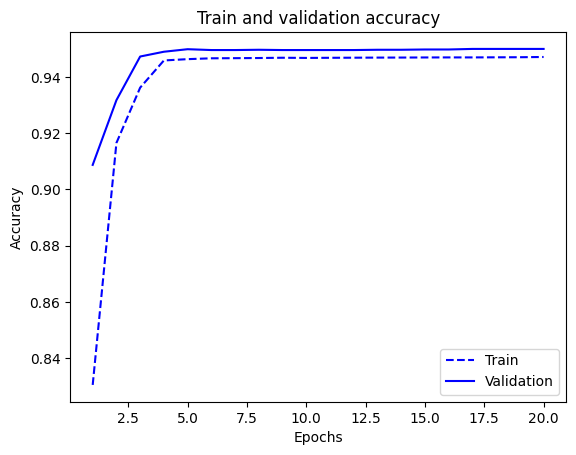

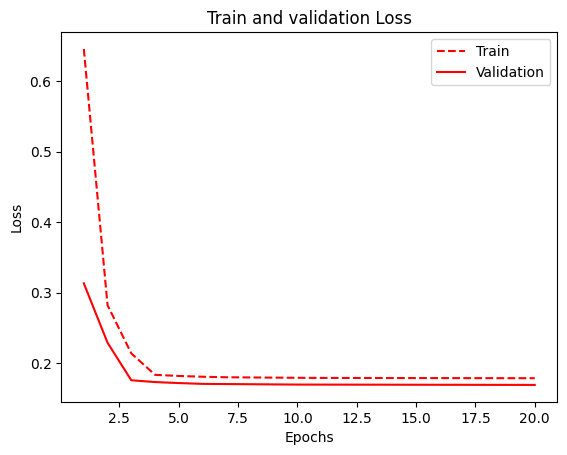

In [28]:
import matplotlib.pyplot as plt
acc = hist.history['accuracy']
loss = hist.history['loss']

val_acc = hist.history['val_accuracy']
val_loss = hist.history['val_loss']


epochs = list(range(1, len(loss) +1))
plt.plot(epochs, acc, 'b--', label='Train')
plt.plot(epochs, val_acc, 'b', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss, 'r--', label='Train')
plt.plot(epochs, val_loss, 'r', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and validation Loss')
plt.legend()
plt.show()

#With ReLU


In [1]:
from keras.models import Sequential
from keras.layers import Conv2D, AveragePooling2D, Flatten, Dense

In [15]:
model2 = Sequential()

#C1 conv layer
model2.add(Conv2D(filters=6, kernel_size=5, strides=1, activation='relu',
                 input_shape = (28, 28, 1), padding='same'))

#S2 pooling layer
model2.add(AveragePooling2D(pool_size=2, strides=2, padding='valid'))

#C3 conv layer
model2.add(Conv2D(filters=16, kernel_size=5, strides=1, activation='relu',
                 padding='valid'))

#S4 pooling layer
model2.add(AveragePooling2D(pool_size=2, strides=2, padding='valid'))

#C5 conv layer
model2.add(Conv2D(filters=120, kernel_size=5, strides=1, activation='relu',
                 padding='valid'))

model2.add(Flatten())

#FC6 fully connected layer
model2.add(Dense(units=84, activation='relu'))

#FC7 layer output layer with sofmax activation
model2.add(Dense(units=10, activation='softmax'))

model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 120)      │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
from keras.datasets import mnist
from keras.utils import to_categorical

# Chargement
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape : ajout de la dimension canal (28, 28) → (28, 28, 1)
x_train = x_train.reshape((60000, 28, 28, 1))
x_test = x_test.reshape((10000, 28, 28, 1))

# Normalisation : 0-255 → 0-1
x_train = x_train.astype('float32') / 255
x_test = x_test.astype('float32') / 255

# One-hot encoding : entier → vecteur
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

In [18]:
def lr_schedule (epoch):
  if epoch <= 2:
    lr = 1e-2
  elif epoch > 2 and epoch <= 5:
    lr = 2e-4
  elif epoch >5 and epoch <= 9:
    lr = 5e-5
  else:
    lr = 1e-5
  return lr

In [19]:
from keras.callbacks import ModelCheckpoint, LearningRateScheduler

lr_scheduler = LearningRateScheduler(lr_schedule)
checkpoint = ModelCheckpoint(filepath='file.keras',
                             monitor='val_acc',
                             mode='max',
                             verbose=1,
                             save_best_only=True)

callbacks = [checkpoint, lr_scheduler]

model2.compile(loss='categorical_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

In [20]:
hist2 = model2.fit(x_train, y_train,
                   batch_size=32,
                   epochs=20,
                   validation_data=(x_test, y_test),
                   callbacks=callbacks,
                   verbose=1, shuffle=True)

Epoch 1/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4493 - loss: 1.6706
Epoch 1: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.6966 - loss: 0.9771 - val_accuracy: 0.9215 - val_loss: 0.2622 - learning_rate: 0.0100
Epoch 2/20
   3/1875 ━━━━━━━━━━━━━━━━━━━━ 1:05 35ms/step - accuracy: 0.9097 - loss: 0.3256

/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/model_checkpoint.py:276: UserWarning: Can save best model only with val_acc available.
  if self._should_save_model(epoch, batch, logs, filepath):


1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9234 - loss: 0.2552
Epoch 2: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9319 - loss: 0.2264 - val_accuracy: 0.9456 - val_loss: 0.1699 - learning_rate: 0.0100
Epoch 3/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9512 - loss: 0.1644
Epoch 3: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9533 - loss: 0.1554 - val_accuracy: 0.9654 - val_loss: 0.1140 - learning_rate: 0.0100
Epoch 4/20
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9652 - loss: 0.1179
Epoch 4: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 23ms/step - accuracy: 0.9657 - loss: 0.1152 - val_accuracy: 0.9669 - val_loss: 0.1077 - learning_rate: 2.0000e-04
Epoch 5/20
1874/1875 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9667 - loss: 0.1113
Epoch 5: finished saving model to file.keras
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 2

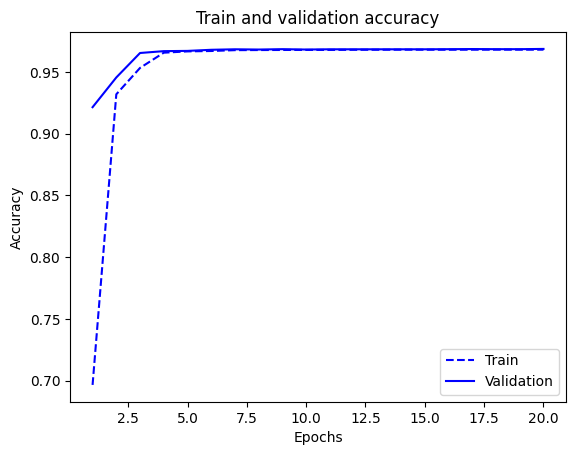

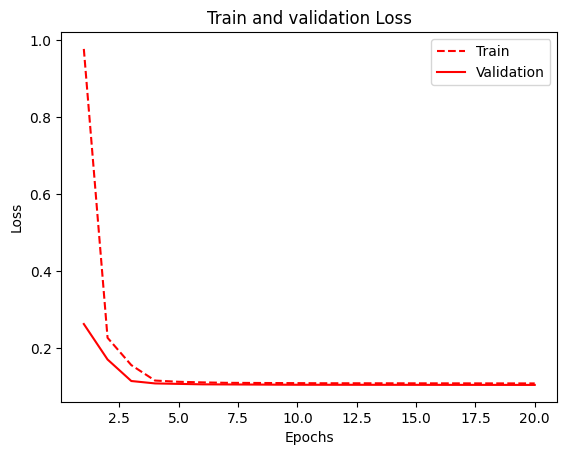

In [21]:
import matplotlib.pyplot as plt
acc2 = hist2.history['accuracy']
loss2 = hist2.history['loss']

val_acc2 = hist2.history['val_accuracy']
val_loss2 = hist2.history['val_loss']


epochs = list(range(1, len(loss2) +1))
plt.plot(epochs, acc2, 'b--', label='Train')
plt.plot(epochs, val_acc2, 'b', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and validation accuracy')
plt.legend()
plt.figure()

plt.plot(epochs, loss2, 'r--', label='Train')
plt.plot(epochs, val_loss2, 'r', label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train and validation Loss')
plt.legend()
plt.show()